In [1]:
# Installazione dei requirements (esegui solo se necessario)
!pip install -r ../../requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import modules

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Import functions

#from cmdstanpy import CmdStanModel
from scipy.optimize import fsolve
#from tensorflow_probability.substrates import numpy as tfp
#tfd = tfp.distributions


c:\dev\GitHub\Progetto_Bayesian_Statistics\.bayesian_stat\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
doners_data = pd.read_csv("C:\\dev\\GitHub\\Progetto_Bayesian_Statistics\\data\\data_donatori.csv")


transconjugants_data = pd.read_csv("C:\\dev\\GitHub\\Progetto_Bayesian_Statistics\\data\\data.csv")
# data.hist()
# doners.hist()
col_map = {"Experiment Index": "i", "Dilution Replicate Index": "k", "Control": "c", "Condition Replicate Index": "j" }
transconjugants_data.rename(columns=col_map, inplace=True)
doners_data.rename(columns=col_map, inplace=True)
# transconjugants_data = transconjugants_data[~transconjugants_data['i'].astype(str).isin(['5','6','7', '8'])].copy()

transconjugants_data = transconjugants_data[~transconjugants_data['i'].astype(str).isin(['5,6','7,8'])].copy()
# transconjugants_data = transconjugants_data[~transconjugants_data['Count'].astype(str).isin(['TMTC'])].copy()
TMTC = 1000
transconjugants_data['Count'] = transconjugants_data['Count'].replace('TMTC', TMTC)

transconjugants_data['c'] = transconjugants_data['c'].replace('No', -1)
transconjugants_data['c'] = transconjugants_data['c'].replace('Yes', 1)

transconjugants_data['j'] = transconjugants_data['j'].replace('A', 0)
transconjugants_data['j'] = transconjugants_data['j'].replace('B', 1)
transconjugants_data['j'] = transconjugants_data['j'].replace('C', 2)


doners_data = (
    doners_data
        .copy()
        # make sure it's a clean string, then split on comma
        .assign(i=lambda df: df['i'].astype(str).str.replace(' ', '').str.split(','))
        .explode('i')          # "5,6" -> ["5","6"] -> two rows
)


for col in transconjugants_data.columns:
    # if col == "i":
    #     continue
    transconjugants_data[col] = pd.to_numeric(transconjugants_data[col], errors='coerce').dropna()
    
for col in doners_data.columns:
    # if col == "i":
    #     continue
    doners_data[col] = pd.to_numeric(doners_data[col], errors='coerce').dropna()
    
transconjugants_data['final_count'] = transconjugants_data["Count"] * (10 ** (-transconjugants_data['Dilution']))
doners_data['final_count'] = doners_data["Count"] * (10 ** (-doners_data['Dilution']))

C:\Users\jclaz\AppData\Local\Temp\ipykernel_40500\628452804.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  transconjugants_data['c'] = transconjugants_data['c'].replace('Yes', 1)
C:\Users\jclaz\AppData\Local\Temp\ipykernel_40500\628452804.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  transconjugants_data['j'] = transconjugants_data['j'].replace('C', 2)


In [4]:
transconjugants_clean_data = (
    transconjugants_data
    .groupby(['i','c','j','IBU','DMSO','Temperature'])['final_count']
    .agg(size='size', count='count', mean='mean', std='std')
)
transconjugants_clean_data

size  count         mean          std
i  c  j IBU   DMSO Temperature                                       
1  -1 0 6.25  0    28              9      9  7655.555556  5224.727531
      1 6.25  0    28              9      9  6788.888889  3186.080839
      2 6.25  0    28              9      9  5488.888889  3577.864043
    1 0 0.00  0    28              9      9  5811.111111  3399.795745
      1 0.00  0    28              9      9  5933.333333  3248.461174
      2 0.00  0    28              9      9  8666.666667  6823.305650
2  -1 0 6.25  0    40              9      9   880.000000   877.382471
      1 6.25  0    40              9      9  1465.555556   735.987621
      2 6.25  0    40              9      9  1187.777778   521.027297
    1 0 0.00  0    40              9      9   920.000000   927.186605
      1 0.00  0    40              9      9  1084.444444   959.272004
      2 0.00  0    40              9      9  1542.222222   874.396617
3  -1 0 50.00 0    28              9      9   644.444444   507.028380
      1 50.00 0    28              9      9  1813.333333   352.384733
      2 50.00 0    28              9      9   956.666667   442.379927
    1 0 0.00  0    28              9      9  1395.555556   346.846908
      1 0.00  0    28              9      9  1348.888889   361.436178
      2 0.00  0    28              9      9   720.000000   616.198020
4  -1 0 50.00 0    40              9      9   948.888889   997.965987
      1 50.00 0    40              9      9  1444.444444   703.990609
      2 50.00 0    40              9      9   746.666667   836.107051
    1 0 0.00  0    40              9      9  1635.555556   786.751408
      1 0.00  0    40              9      9   974.444444   613.577850
      2 0.00  0    40              9      9   695.555556   765.165196
5  -1 0 50.00 10   28              9      9  3644.444444  4786.207035
      1 50.00 10   28              9      9  3577.777778  4828.244447
      2 50.00 10   28              9      9  3788.888889  4696.393415
6  -1 0 6.25  10   28              9      9  3711.111111  4730.603673
      1 6.25  10   28              9      9  3844.444444  4626.853983
      2 6.25  10   28              9      9  3966.666667  4542.576361
7  -1 0 6.25  10   40              9      9  4422.222222  4419.495949
      1 6.25  10   40              9      9  4133.333333  4547.801667
      2 6.25  10   40              9      9  4366.666667  4366.634860
8  -1 0 50.00 10   40              9      9  4355.555556  4477.753653
      1 50.00 10   40              9      9  4911.111111  4061.232708
      2 50.00 10   40              9      9  4500.000000  4207.730980
9  -1 0 0.00  10   28              9      9   656.666667   762.725377
      1 0.00  10   28              9      9   464.444444   490.563735
    1 0 0.00  0    28              9      9   738.888889   578.066701
      1 0.00  0    28              9      9   368.888889   353.816494
10 -1 0 0.00  10   40              9      9  1105.555556  1488.305338
      1 0.00  10   40              9      9  1296.666667  1316.529529
    1 0 0.00  0    40              9      9   845.555556  1013.399121
      1 0.00  0    40              9      9   798.888889   971.911061

In [5]:
doners__clean_data_clean_data = (
    doners_data
    .groupby(['i','IBU','DMSO','Temperature'])['final_count']
    .agg(size='size', count='count', mean='mean', std='std')
)
doners__clean_data_clean_data

,,,,size,count,mean,std
i,IBU,DMSO,Temperature,,,,
1,6.25,0,28,9,9,7.655556e+07,7.250709e+07
2,6.25,0,40,9,9,1.116667e+08,6.151423e+07
3,50.00,0,28,9,9,3.344444e+07,2.735467e+07
4,50.00,0,40,9,9,1.425556e+08,1.412410e+08
5,50.00,10,28,9,9,3.744444e+07,3.248119e+07
6,50.00,10,28,9,9,3.744444e+07,3.248119e+07
7,50.00,10,40,9,9,5.111111e+07,3.577515e+07
8,50.00,10,40,9,9,5.111111e+07,3.577515e+07
9,0.00,10,28,9,9,2.286667e+08,1.872645e+08


In [6]:
avg_final_trans = (
    transconjugants_data
    .groupby(['i', 'c', 'j', 'IBU', 'DMSO', 'Temperature'], as_index=False)['final_count']
    .mean()
    .rename(columns={'final_count': 'avg_final_count'})
)

std_final_trans = (
    transconjugants_data
    .groupby(['i', 'c', 'j', 'IBU', 'DMSO', 'Temperature'], as_index=False)['final_count']
    .std()
    .rename(columns={'final_count': 'std_final_count'})
)

transconjugants_clean_data = avg_final_trans
transconjugants_clean_data["std"] = std_final_trans["std_final_count"]
transconjugants_clean_data["mean"] = avg_final_trans["avg_final_count"]


avg_final_doner = (
    doners_data
    .groupby(['i', 'IBU', 'DMSO', 'Temperature'], as_index=False)['final_count']
    .mean()
    .rename(columns={'final_count': 'avg_final_count'})
)

std_final_doner = (
    doners_data
    .groupby(['i', 'IBU', 'DMSO', 'Temperature'], as_index=False)['final_count']
    .std()
    .rename(columns={'final_count': 'std_final_count'})
)

doners__clean_data = avg_final_doner
doners__clean_data["std"] = std_final_doner["std_final_count"]
doners__clean_data["mean"] = avg_final_doner["avg_final_count"]



In [7]:
doners__clean_data

,i,IBU,DMSO,Temperature,avg_final_count,std,mean
0,1,6.25,0,28,7.655556e+07,7.250709e+07,7.655556e+07
1,2,6.25,0,40,1.116667e+08,6.151423e+07,1.116667e+08
2,3,50.00,0,28,3.344444e+07,2.735467e+07,3.344444e+07
3,4,50.00,0,40,1.425556e+08,1.412410e+08,1.425556e+08
4,5,50.00,10,28,3.744444e+07,3.248119e+07,3.744444e+07
5,6,50.00,10,28,3.744444e+07,3.248119e+07,3.744444e+07
6,7,50.00,10,40,5.111111e+07,3.577515e+07,5.111111e+07
7,8,50.00,10,40,5.111111e+07,3.577515e+07,5.111111e+07
8,9,0.00,10,28,2.286667e+08,1.872645e+08,2.286667e+08
9,10,0.00,10,40,2.286667e+08,1.872645e+08,2.286667e+08


In [8]:
transconjugants_clean_data

,i,c,j,IBU,DMSO,Temperature,avg_final_count,std,mean
0,1,-1,0,6.25,0,28,7655.555556,5224.727531,7655.555556
1,1,-1,1,6.25,0,28,6788.888889,3186.080839,6788.888889
2,1,-1,2,6.25,0,28,5488.888889,3577.864043,5488.888889
3,1,1,0,0.00,0,28,5811.111111,3399.795745,5811.111111
4,1,1,1,0.00,0,28,5933.333333,3248.461174,5933.333333
5,1,1,2,0.00,0,28,8666.666667,6823.305650,8666.666667
6,2,-1,0,6.25,0,40,880.000000,877.382471,880.000000
7,2,-1,1,6.25,0,40,1465.555556,735.987621,1465.555556
8,2,-1,2,6.25,0,40,1187.777778,521.027297,1187.777778
9,2,1,0,0.00,0,40,920.000000,927.186605,920.000000


In [9]:
transconjugants_clean_data = transconjugants_clean_data.merge(
    doners__clean_data[['i', 'avg_final_count']].rename(
        columns={'avg_final_count': 'doner_mean'}
    ),
    on='i',
    how='left'
)


In [10]:
transconjugants_clean_data['ratio'] = np.log10(
    transconjugants_clean_data['mean'] / transconjugants_clean_data['doner_mean']
)


In [11]:
transconjugants_clean_data

,i,c,j,IBU,DMSO,Temperature,avg_final_count,std,mean,doner_mean,ratio
0,1,-1,0,6.25,0,28,7655.555556,5224.727531,7655.555556,7.655556e+07,-4.000000
1,1,-1,1,6.25,0,28,6788.888889,3186.080839,6788.888889,7.655556e+07,-4.052178
2,1,-1,2,6.25,0,28,5488.888889,3577.864043,5488.888889,7.655556e+07,-4.144492
3,1,1,0,0.00,0,28,5811.111111,3399.795745,5811.111111,7.655556e+07,-4.119718
4,1,1,1,0.00,0,28,5933.333333,3248.461174,5933.333333,7.655556e+07,-4.110678
5,1,1,2,0.00,0,28,8666.666667,6823.305650,8666.666667,7.655556e+07,-3.946125
6,2,-1,0,6.25,0,40,880.000000,877.382471,880.000000,1.116667e+08,-5.103441
7,2,-1,1,6.25,0,40,1465.555556,735.987621,1465.555556,1.116667e+08,-4.881921
8,2,-1,2,6.25,0,40,1187.777778,521.027297,1187.777778,1.116667e+08,-4.973188
9,2,1,0,0.00,0,40,920.000000,927.186605,920.000000,1.116667e+08,-5.084136


## Frequentist Data Analysis



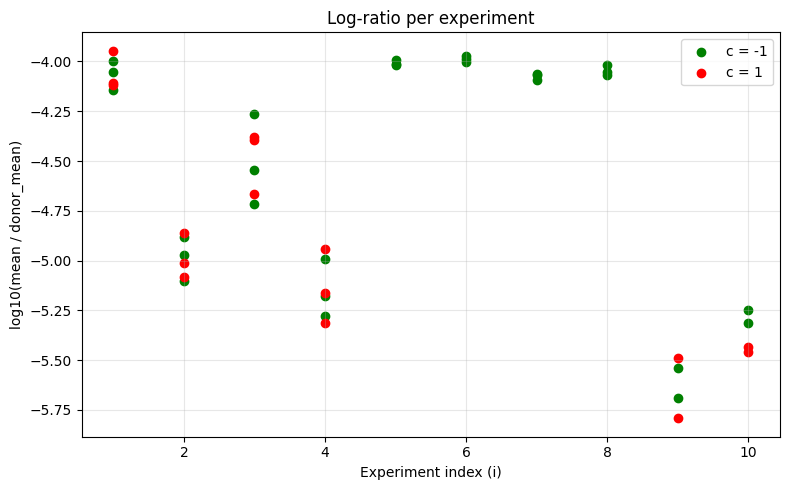

In [12]:
import numpy as np
import matplotlib.pyplot as plt

df = transconjugants_clean_data.copy()
mask_ctrl = df['c'] == -1
mask_treat = df['c'] == 1

plt.figure(figsize=(8, 5))

plt.scatter(df.loc[mask_ctrl, 'i'],
            df.loc[mask_ctrl, 'ratio'],
            label='c = -1', color='green')

plt.scatter(df.loc[mask_treat, 'i'],
            df.loc[mask_treat, 'ratio'],
            label='c = 1', color='red')

plt.xlabel('Experiment index (i)')
plt.ylabel('log10(mean / donor_mean)')
plt.title('Log-ratio per experiment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Outlier Analysis: data.csv

C:\Users\jclaz\AppData\Local\Temp\ipykernel_40500\3927222826.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='ratio', data=transconjugants_clean_data, palette=['#2ecc71', '#e74c3c'])


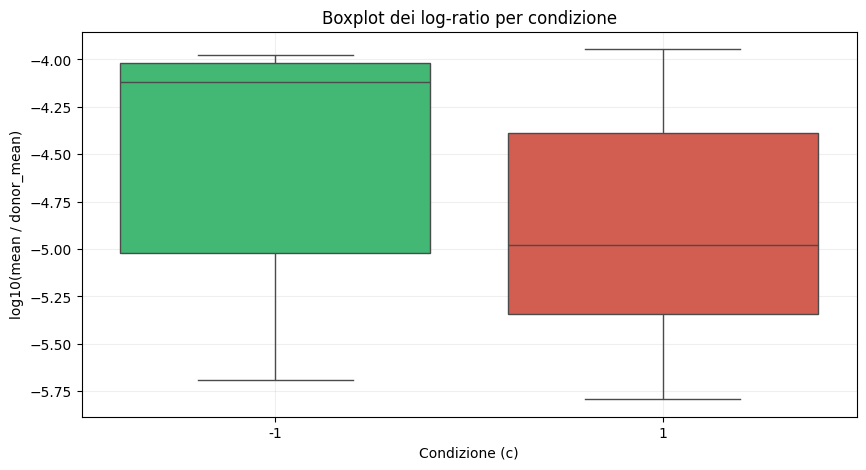

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(x='c', y='ratio', data=transconjugants_clean_data, palette=['#2ecc71', '#e74c3c'])
plt.xlabel('Condizione (c)')
plt.ylabel('log10(mean / donor_mean)')
plt.title('Boxplot dei log-ratio per condizione')
plt.grid(True, alpha=0.2)
plt.show()

### Predictive Tail Probabilities Outlier Analysis

In [14]:
from scipy.stats import norm

def predictive_p_values(df, group_cols, value_col, mean_col, std_col):
    p_values = []
    for idx, row in df.iterrows():
        mu = row[mean_col]
        sigma = row[std_col]
        y = row[value_col]
        if np.isnan(mu) or np.isnan(sigma) or sigma == 0:
            p = np.nan
        else:
            p_upper = 1 - norm.cdf(y, loc=mu, scale=sigma)
            p_lower = norm.cdf(y, loc=mu, scale=sigma)
            p = min(p_upper, p_lower)
        p_values.append(p)
    return np.array(p_values)

df = transconjugants_clean_data.copy()
df['predictive_p'] = predictive_p_values(df, group_cols=['i','c','j','IBU','DMSO','Temperature'], value_col='mean', mean_col='mean', std_col='std')

outlier_mask = df['predictive_p'] < 0.05
print(f"Numero di outlier (p < 0.05): {outlier_mask.sum()} su {len(df)}")
df[['i','c','j','IBU','DMSO','Temperature','mean','predictive_p']][outlier_mask]

Numero di outlier (p < 0.05): 0 su 44


,i,c,j,IBU,DMSO,Temperature,mean,predictive_p


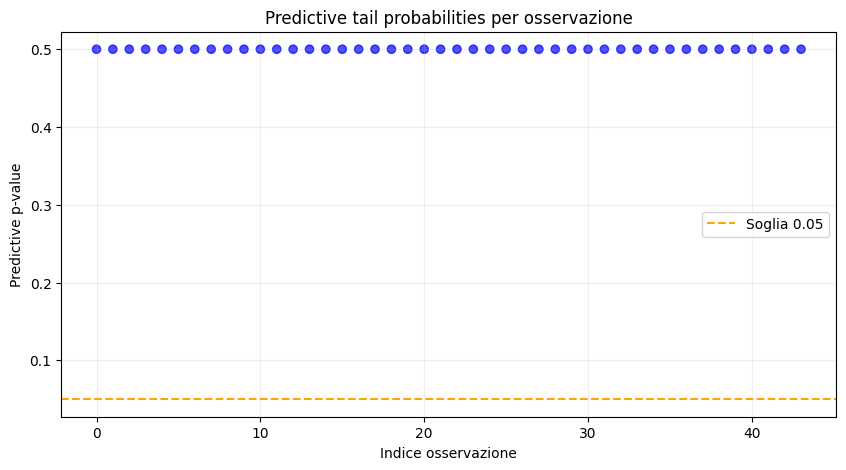

In [15]:
plt.figure(figsize=(10, 5))
plt.scatter(df.index, df['predictive_p'], c=outlier_mask.map({True: 'red', False: 'blue'}), alpha=0.7)
plt.axhline(0.05, color='orange', linestyle='--', label='Soglia 0.05')
plt.xlabel('Indice osservazione')
plt.ylabel('Predictive p-value')
plt.title('Predictive tail probabilities per osservazione')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Outlier per sottogruppo (p < 0.05): 0 su 44


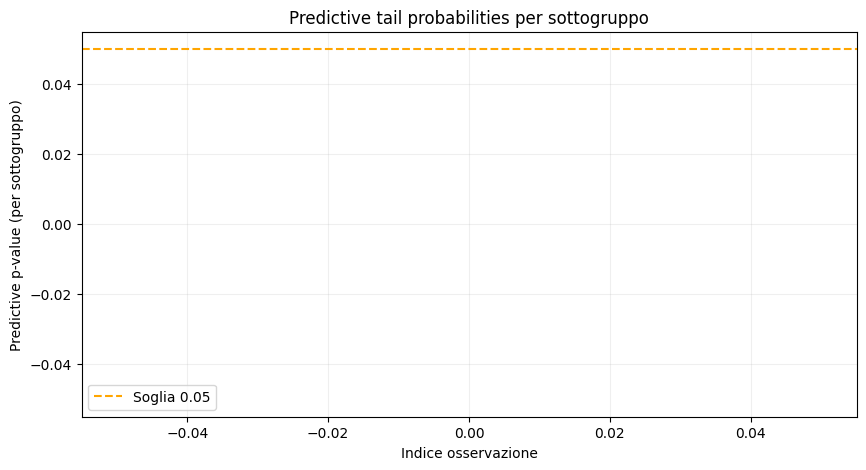

In [16]:
from scipy.stats import norm

def predictive_p_values_grouped(df, group_cols, value_col):
    df = df.copy()
    p_values = np.full(len(df), np.nan)
    grouped = df.groupby(group_cols)
    for name, group in grouped:
        mu = group[value_col].mean()
        sigma = group[value_col].std()
        if np.isnan(sigma) or sigma == 0:
            continue
        vals = group[value_col].values
        p_upper = 1 - norm.cdf(vals, loc=mu, scale=sigma)
        p_lower = norm.cdf(vals, loc=mu, scale=sigma)
        p = np.minimum(p_upper, p_lower)
        p_values[group.index] = p
    return p_values

transconjugants_clean_data['predictive_p_group'] = predictive_p_values_grouped(
    transconjugants_clean_data,
    group_cols=['i', 'c', 'j', 'IBU', 'DMSO', 'Temperature'],
    value_col='mean'
)

outlier_mask_group = transconjugants_clean_data['predictive_p_group'] < 0.05
print(f"Outlier per sottogruppo (p < 0.05): {outlier_mask_group.sum()} su {len(transconjugants_clean_data)}")
transconjugants_clean_data.loc[outlier_mask_group, ['i','c','j','IBU','DMSO','Temperature','mean','predictive_p_group']]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.scatter(transconjugants_clean_data.index, transconjugants_clean_data['predictive_p_group'],
            c=outlier_mask_group.map({True: 'red', False: 'blue'}), alpha=0.7)
plt.axhline(0.05, color='orange', linestyle='--', label='Soglia 0.05')
plt.xlabel('Indice osservazione')
plt.ylabel('Predictive p-value (per sottogruppo)')
plt.title('Predictive tail probabilities per sottogruppo')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [17]:
group_cols = ['i','c','j','IBU','DMSO','Temperature']
display_cols = group_cols + ['mean','predictive_p_group']
outlier_df = transconjugants_clean_data.loc[outlier_mask_group, display_cols]
if outlier_df.empty:
    print("Nessun outlier trovato nei sottogruppi con p < 0.05.")
else:
    for name, group in outlier_df.groupby(group_cols):
        print(f"\nGruppo: {dict(zip(group_cols, name))} - {len(group)} outlier")
        display(group.reset_index(drop=True))

Nessun outlier trovato nei sottogruppi con p < 0.05.


## Outlier Analysis: data_donatori.csv

C:\Users\jclaz\AppData\Local\Temp\ipykernel_40500\3354570827.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='i', y='mean', data=doners__clean_data, palette='Set2')


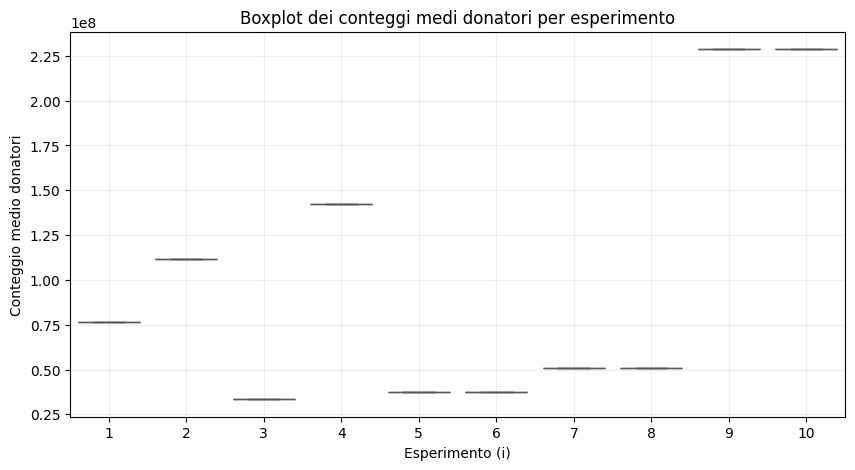

In [18]:
doner_group_cols = ['i', 'IBU', 'DMSO', 'Temperature']
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
sns.boxplot(x='i', y='mean', data=doners__clean_data, palette='Set2')
plt.xlabel('Esperimento (i)')
plt.ylabel('Conteggio medio donatori')
plt.title('Boxplot dei conteggi medi donatori per esperimento')
plt.grid(True, alpha=0.2)
plt.show()

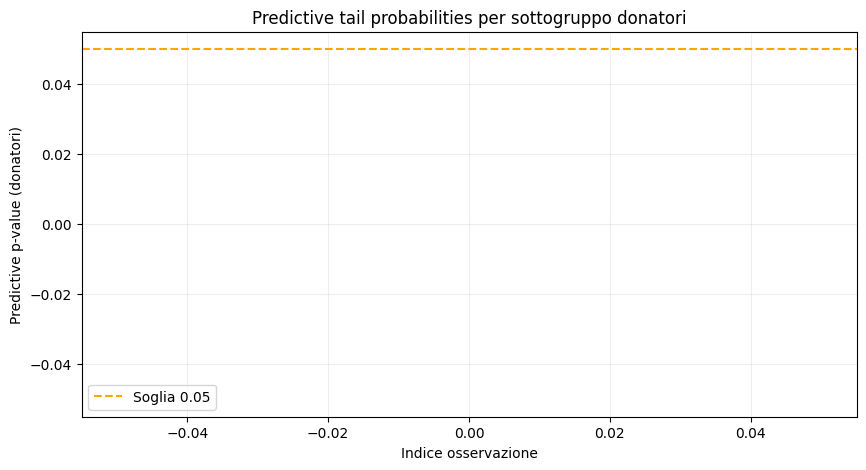

Nessun outlier trovato nei donatori con p < 0.05.


In [ ]:
def predictive_p_values_grouped(df, group_cols, value_col):
    df = df.copy()
    p_values = np.full(len(df), np.nan)
    grouped = df.groupby(group_cols)
    for name, group in grouped:
        mu = group[value_col].mean()
        sigma = group[value_col].std()
        if np.isnan(sigma) or sigma == 0:
            continue
        vals = group[value_col].values
        p_upper = 1 - norm.cdf(vals, loc=mu, scale=sigma)
        p_lower = norm.cdf(vals, loc=mu, scale=sigma)
        p = np.minimum(p_upper, p_lower)
        p_values[group.index] = p
    return p_values

doners__clean_data['predictive_p_group'] = predictive_p_values_grouped(
    doners__clean_data,
    group_cols=doner_group_cols,
    value_col='mean'
)
outlier_mask_doner_group = doners__clean_data['predictive_p_group'] < 0.05
outlier_doner_df = doners__clean_data.loc[outlier_mask_doner_group, doner_group_cols + ['mean','predictive_p_group']]

plt.figure(figsize=(10, 5))
plt.scatter(doners__clean_data.index, doners__clean_data['predictive_p_group'],
            c=outlier_mask_doner_group.map({True: 'red', False: 'blue'}), alpha=0.7)
plt.axhline(0.05, color='orange', linestyle='--', label='Soglia 0.05')
plt.xlabel('Indice osservazione')
plt.ylabel('Predictive p-value (donatori)')
plt.title('Predictive tail probabilities per sottogruppo donatori')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

if outlier_doner_df.empty:
    print("Nessun outlier trovato nei donatori con p < 0.05.")
else:
    for name, group in outlier_doner_df.groupby(doner_group_cols):
        print(f"\nGruppo donatori: {dict(zip(doner_group_cols, name))} - {len(group)} outlier")
        display(group.reset_index(drop=True))